11.Wine Quality Analysis and Naïve Bayes Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score


1. Perform basic EDA by displaying the first five records, missing values,
descriptive statistics, and quality distribution.

First Five Records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8    

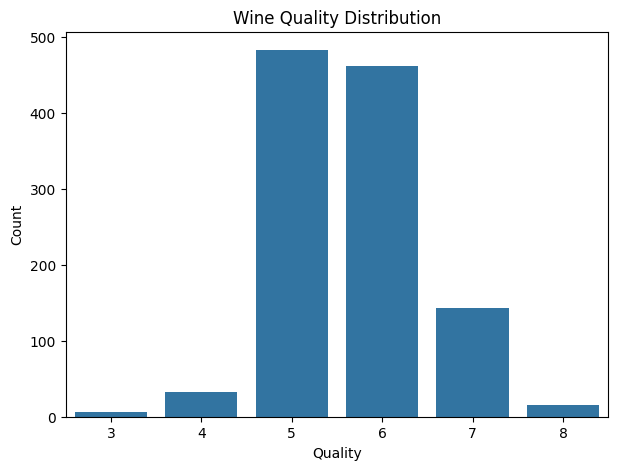

In [2]:
# 1. Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WineQT.csv")


# Display first five records
print("First Five Records:")
print(df.head())


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Quality distribution
print("\nQuality Distribution:")
print(df["quality"].value_counts().sort_index())


# Plot quality distribution
plt.figure(figsize=(7, 5))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()


2. Plot a scatter plot of alcohol vs pH, a histogram of alcohol, and a box plot of
alcohol by quality.

In [ ]:
# 2. Data Visualization

# Scatter plot: Alcohol vs pH
plt.figure(figsize=(7, 5))
plt.scatter(df["alcohol"], df["pH"])
plt.title("Alcohol vs pH")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.show()


# Histogram of Alcohol
plt.figure(figsize=(7, 5))
plt.hist(df["alcohol"], bins=20, edgecolor="black")
plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()


# Box plot of Alcohol by Quality
plt.figure(figsize=(7, 5))
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Alcohol by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

3. Apply Gaussian Naïve Bayes to predict quality using the numerical features,
with an 80:20 train-test split.

In [ ]:
# 3. Gaussian Naïve Bayes Classification

# Separate features and target
# Id is removed because it is only an identifier
X = df.drop(columns=["quality", "Id"])
y = df["quality"]


# Split dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Standardize the numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Create Gaussian Naïve Bayes model
model = GaussianNB()


# Train the model
model.fit(X_train, y_train)


# Predict quality
y_pred = model.predict(X_test)


4. Display the classification report and accuracy.

In [ ]:
# 4. Classification Report and Accuracy

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")